**05 — Sparse-slice MedGS joint reconstruction: background-aware interpolation**

Three experiments use the same data, model, sparse sampling and segmentation loss. They differ only in the weight of the segmentation branch: \(\lambda_{\mathrm{seg}}\in\{1,2,3\}\).

The segmentation loss includes an in-between background penalty. It suppresses foreground between known empty masks and near a known empty endpoint without inventing an intermediate tumor shape.

# 1. Data and configuration

In [1]:
from pathlib import Path

import json
import numpy as np
import os
import pandas as pd
import shutil
import subprocess
import sys
import torch
from IPython.display import display
from PIL import Image
from typing import Any

from medgs4d.data import (
    grayscale_to_rgb_uint8,
    load_phase_volume,
    load_study_manifest,
    window_hu_to_uint8,
)
from medgs4d.evaluation import calculate_reconstruction_metrics
from medgs4d.mesh_transfer import evaluate_mesh_against_reference
from medgs4d.meshes import (
    TriangleMesh,
    binary_dice,
    binary_iou,
    load_mesh_npz,
    write_ply,
)
from medgs4d.rtstruct import load_geometry
from medgs4d.sparse_joint_visualization import (
    show_sparse_joint_anatomy_3d,
    show_sparse_joint_slice_browser,
)

STACK_ROOT = Path("/home/jovyan/shared/mtm_medgs_stack")
MEDGS_REPO = STACK_ROOT / "repo" / "MedGS"
STUDY_DIR = (
        STACK_ROOT
        / "data"
        / "tcia_4d_lung"
        / "prepared"
        / "patient117_20001024_annotated"
)

PHASE = 0.0
REPRESENTATION = "denoised"

SLICE_STRIDE = 3
ITERATIONS = 30_000
POLY_DEGREE = 7
BATCH_SIZE = 3

LAMBDA_IMG = 1.0
DICE_WEIGHT = 1.0
BG_INTER_WEIGHT = 0.5

ALPHA_MIN = 0.2
ALPHA_MAX = 0.8

MASK_THRESHOLD = 150
MESH_THRESHOLD = 0
RENDER_CHUNKS = 4

TEST_ITERATIONS = [5_000, 10_000, 15_000, 20_000, 25_000, 30_000]
TRAIN_HISTORY_INTERVAL = 100

TUMOR_START = 86
TUMOR_END = 92
RANGE_START = TUMOR_START - 5 * SLICE_STRIDE
RANGE_END = TUMOR_END + 5 * SLICE_STRIDE

FORCE_TRAIN = False

PHASE_TAG = f"{int(PHASE):02d}"
PHASE_DIR = (
        STUDY_DIR
        / "rtstruct_mesh"
        / "tumor_4d"
        / f"phase_{PHASE_TAG}"
)

V11_ROOT = (
        STACK_ROOT
        / "results"
        / "canonical"
        / STUDY_DIR.name
        / (
            f"phase{PHASE_TAG}_joint_local{RANGE_START}_{RANGE_END}_"
            f"stride{SLICE_STRIDE}_poly{POLY_DEGREE}_bginter_v11"
        )
)

IMG_DATASET = V11_ROOT / "dataset_img"
MASK_DATASET = V11_ROOT / "dataset_mask"
TOOLS_DIR = V11_ROOT / "tools"
PATCHED_TRAIN = TOOLS_DIR / "train_joint_bginter_v11.py"

print("Study:", STUDY_DIR)
print("Experiment root:", V11_ROOT)

Study: /home/jovyan/shared/mtm_medgs_stack/data/tcia_4d_lung/prepared/patient117_20001024_annotated
Experiment root: /home/jovyan/shared/mtm_medgs_stack/results/canonical/patient117_20001024_annotated/phase00_joint_local71_107_stride3_poly7_bginter_v11


In [2]:
study = load_study_manifest(STUDY_DIR)

ct_hu = np.asarray(
    load_phase_volume(
        study,
        PHASE,
        representation=REPRESENTATION,
        mmap_mode="r",
    )
)

reference_mask = np.load(
    PHASE_DIR / "mask.npy",
    allow_pickle=False,
).astype(bool)

geometry = load_geometry(PHASE_DIR / "geometry.json")
reference_mesh = load_mesh_npz(PHASE_DIR / "mesh_raw.npz")

assert ct_hu.shape == reference_mask.shape == geometry.shape_zyx

evaluation_slices = list(range(RANGE_START, RANGE_END + 1))
observed_slices = list(range(RANGE_START, RANGE_END + 1, SLICE_STRIDE))
observed_set = set(observed_slices)

missing_slices = [
    i for i in evaluation_slices
    if i not in observed_set
]

tumor_slices = list(range(TUMOR_START, TUMOR_END + 1))
tumor_missing_slices = [
    i for i in tumor_slices
    if i not in observed_set
]

observed_tumor_slices = [
    i for i in observed_slices
    if reference_mask[i].any()
]

observed_empty_slices = [
    i for i in observed_slices
    if not reference_mask[i].any()
]

assert observed_tumor_slices == [86, 89, 92]
assert len(observed_empty_slices) == 10

ground_truth_ct = np.stack(
    [
        window_hu_to_uint8(
            ct_hu[i],
            study.hu_window,
        )
        for i in evaluation_slices
    ]
).astype(np.float32) / 255.0

reference_mask_eval = reference_mask[evaluation_slices]

print(
    f"Local CT range: {RANGE_START}..{RANGE_END}; "
    f"{len(observed_slices)} observed frames, "
    f"{len(missing_slices)} held-out slices."
)
print("Observed tumor slices:", observed_tumor_slices)
print("Held-out tumor slices:", tumor_missing_slices)

Local CT range: 71..107; 13 observed frames, 24 held-out slices.
Observed tumor slices: [86, 89, 92]
Held-out tumor slices: [87, 88, 90, 91]


In [3]:
if FORCE_TRAIN and V11_ROOT.exists():
    shutil.rmtree(V11_ROOT)

for root in (IMG_DATASET, MASK_DATASET):
    shutil.rmtree(root, ignore_errors=True)
    (root / "original").mkdir(parents=True)
    (root / "mirror").mkdir(parents=True)

rows = []

for frame_index, slice_index in enumerate(observed_slices):
    ct_gray = window_hu_to_uint8(
        ct_hu[slice_index],
        study.hu_window,
    )
    ct_rgb = grayscale_to_rgb_uint8(ct_gray)

    mask_gray = reference_mask[slice_index].astype(np.uint8) * 255
    mask_rgb = grayscale_to_rgb_uint8(mask_gray)

    filename = f"{frame_index:04d}.png"

    Image.fromarray(ct_rgb).save(
        IMG_DATASET / "original" / filename
    )
    Image.fromarray(
        np.fliplr(ct_rgb).copy()
    ).save(
        IMG_DATASET / "mirror" / filename
    )

    Image.fromarray(mask_rgb).save(
        MASK_DATASET / "original" / filename
    )
    Image.fromarray(
        np.fliplr(mask_rgb).copy()
    ).save(
        MASK_DATASET / "mirror" / filename
    )

    rows.append(
        {
            "FrameIndex": frame_index,
            "SliceIndex": slice_index,
            "TumorMask": bool(reference_mask[slice_index].any()),
        }
    )

observed_manifest = pd.DataFrame(rows)
V11_ROOT.mkdir(parents=True, exist_ok=True)
observed_manifest.to_csv(
    V11_ROOT / "observed_slices.csv",
    index=False,
)

print("Observed MedGS frames:")
display(observed_manifest)

Observed MedGS frames:


,FrameIndex,SliceIndex,TumorMask
0,0,71,False
1,1,74,False
2,2,77,False
3,3,80,False
4,4,83,False
5,5,86,True
6,6,89,True
7,7,92,True
8,8,95,False
9,9,98,False


CT and RTSTRUCT masks around the tumor:


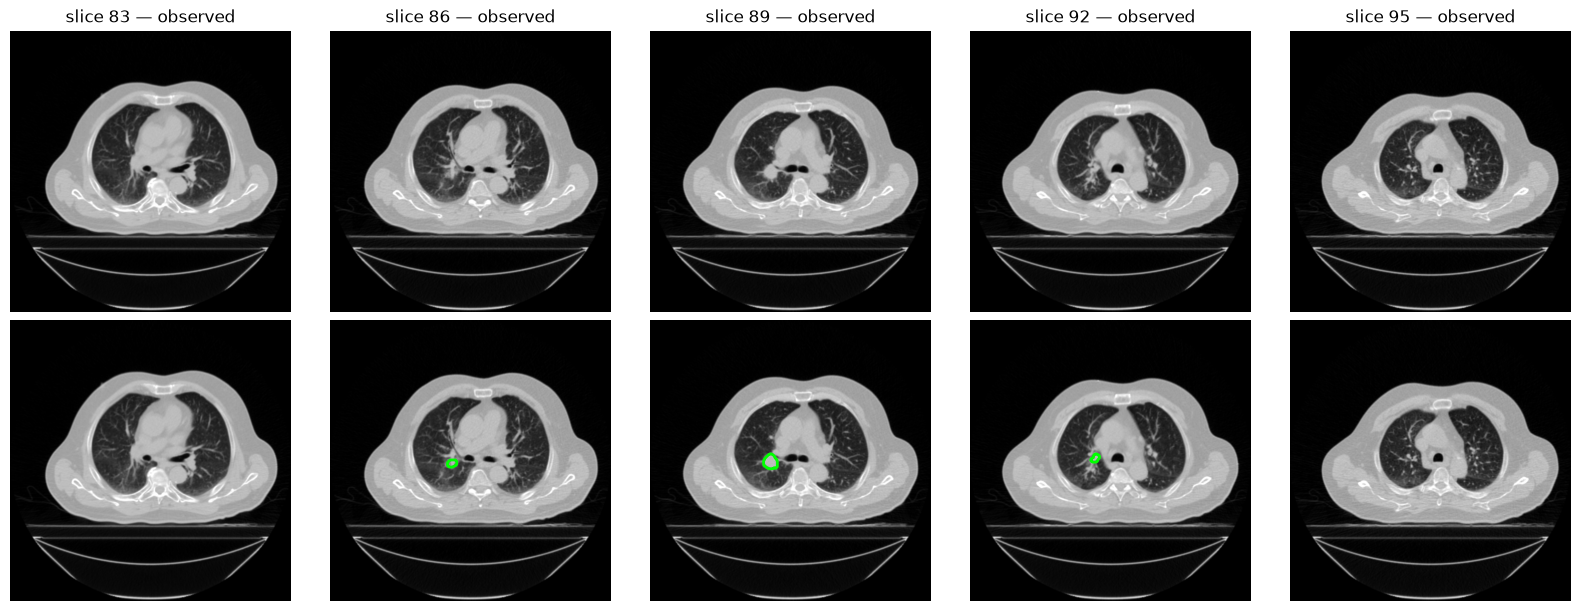

In [14]:
import matplotlib.pyplot as plt

example_slices = [83, 86, 89, 92, 95]

print("CT and RTSTRUCT masks around the tumor:")

figure, axes = plt.subplots(
    2,
    len(example_slices),
    figsize=(16, 6),
    constrained_layout=True,
)

for column, slice_index in enumerate(example_slices):
    status = "observed" if slice_index in observed_set else "missing"
    ct_slice = window_hu_to_uint8(
        ct_hu[slice_index],
        study.hu_window,
    )

    axes[0, column].imshow(ct_slice, cmap="gray")
    axes[0, column].set_title(f"slice {slice_index} — {status}")

    axes[1, column].imshow(ct_slice, cmap="gray")
    if reference_mask[slice_index].any():
        axes[1, column].contour(
            reference_mask[slice_index],
            levels=[0.5],
            colors="lime",
            linewidths=2,
        )

    for axis in axes[:, column]:
        axis.axis("off")

plt.show()

# 2. Parameters and loss functions

### Parameters

- **stride** ($s=3$): distance in original CT slice indices between consecutive observed training frames.
- **poly_degree** ($p=7$): degree of the polynomial parameterization used by MedGS to vary Gaussian parameters along the frame coordinate.
- **$\lambda_{\mathrm{img}}$ and $\lambda_{\mathrm{seg}}$**: weights of the image and segmentation branches in the joint objective.
- **$\alpha$**: relative location of an in-between render between two observed frames. Here $\alpha \in [0.2, 0.8]$, where $\alpha=0$ corresponds to the left endpoint and $\alpha=1$ to the right endpoint.
- **threshold** ($\tau=150$): cutoff used to convert rendered segmentation scores in $[0,255]$ into binary masks for 2D evaluation. It is not part of the training loss. Mesh reconstruction uses the upstream automatic threshold with `--thresh 0`.

### Image loss

The image branch uses the MedGS reconstruction objective:

$$
\mathcal{L}_{\mathrm{img}}
=
2\mathcal{L}_{1,\mathrm{img}}
+
0.5\mathcal{L}_{1,\mathrm{img}}^{\mathrm{inter}}
+
0.25\mathcal{L}_{\sigma}
+
0.25(1-\mathrm{SSIM})
$$

Here, $\mathcal{L}_{1,\mathrm{img}}^{\mathrm{inter}}$ is the image reconstruction loss for a randomly sampled position between observed frames.

### Segmentation loss on observed frames

For an observed ground-truth mask $M$ and rendered segmentation $\hat{M}$, the Dice loss is:

$$
\mathcal{L}_{\mathrm{Dice}}
=
1-
\frac{2\sum \hat{M}M+\varepsilon}
{\sum \hat{M}+\sum M+\varepsilon}
$$

The segmentation loss on observed frames is:

$$
\mathcal{L}_{\mathrm{seg}}^{\mathrm{obs}}
=
2\mathcal{L}_{1,\mathrm{seg}}
+
\mathcal{L}_{\mathrm{Dice}}
+
0.5\mathcal{L}_{\sigma}
$$

### In-between background loss

Let $A$ and $B$ be two observed endpoint masks and let $\hat{M}_{\alpha}$ be the segmentation rendered at an intermediate position $\alpha$.

The additional background loss is:

$$
\mathcal{L}_{\mathrm{bg,inter}}
=
w(A,B,\alpha)
\cdot
\mathrm{mean}(|\hat{M}_{\alpha}|)
$$

The weight $w(A,B,\alpha)$ depends on the endpoint masks:

| Interval | Weight |
|---|---:|
| empty $\rightarrow$ empty | $1$ |
| empty $\rightarrow$ tumor | $(1-\alpha)^2$ |
| tumor $\rightarrow$ empty | $\alpha^2$ |
| tumor $\rightarrow$ tumor | $0$ |

The four cases have different roles:

- **Fixed penalty — empty $\rightarrow$ empty:** both endpoint masks are empty, so foreground is suppressed throughout the interval with constant weight $1$.
- **Weighted penalty — empty $\rightarrow$ tumor:** the penalty is strongest near the known empty endpoint and decreases toward the tumor endpoint according to $(1-\alpha)^2$.
- **Weighted penalty — tumor $\rightarrow$ empty:** the penalty increases toward the known empty endpoint according to $\alpha^2$.
- **No penalty — tumor $\rightarrow$ tumor:** no background constraint is imposed because the true intermediate tumor shape is unknown.

The complete segmentation loss is:

$$
\mathcal{L}_{\mathrm{seg}}
=
\mathcal{L}_{\mathrm{seg}}^{\mathrm{obs}}
+
0.5\mathcal{L}_{\mathrm{bg,inter}}
$$

### Joint loss

The complete joint objective is:

$$
\mathcal{L}_{\mathrm{joint}}
=
\lambda_{\mathrm{img}}\mathcal{L}_{\mathrm{img}}
+
\lambda_{\mathrm{seg}}\mathcal{L}_{\mathrm{seg}}
$$

Experiments A, B and C differ only in $\lambda_{\mathrm{seg}}$. The data, sparse sampling, model configuration and definitions of the loss terms remain fixed.

# 3. Experiments

- **A — $\lambda_{\mathrm{seg}} = 1$**: equal outer weights for image and segmentation branches.
- **B — $\lambda_{\mathrm{seg}} = 2$**: the full segmentation objective contributes twice as strongly as the image branch.
- **C — $\lambda_{\mathrm{seg}} = 3$**: strongest segmentation weighting, testing whether the background constraint can further reduce false-positive extent without losing too much tumor overlap.

All other settings are identical.

In [5]:
EXPERIMENTS = [
    {"key": "A", "label": "A: lambda_seg=1", "lambda_seg": 1.0},
    {"key": "B", "label": "B: lambda_seg=2", "lambda_seg": 2.0},
    {"key": "C", "label": "C: lambda_seg=3", "lambda_seg": 3.0},
]

print("Experiments:")
display(pd.DataFrame(EXPERIMENTS))

Experiments:


,key,label,lambda_seg
0,A,A: lambda_seg=1,1.0
1,B,B: lambda_seg=2,2.0
2,C,C: lambda_seg=3,3.0


# 4. Training and evaluation pipeline

In [6]:
def build_v11_train_script() -> Path:
    """Create a private MedGS train.py with Dice and background-aware in-between loss."""

    TOOLS_DIR.mkdir(parents=True, exist_ok=True)

    source = (MEDGS_REPO / "train.py").read_text(
        encoding="utf-8"
    )

    if "import csv\n" not in source:
        source = source.replace(
            "import os\n",
            "import os\nimport csv\n",
            1,
        )

    joint_start = source.index("def training_joint(")
    joint_end = source.index(
        "def prepare_output_and_logger",
        joint_start,
    )
    joint_source = source[joint_start:joint_end]

    # Replace only the segmentation section inside training_joint().
    # Using start/end anchors is less brittle than matching the whole
    # upstream block line-for-line.
    seg_start = joint_source.index(
        "        outputs_seg = {}\n"
    )
    seg_end = joint_source.index(
        '        render_seg_curr = outputs_seg["camera"]["render"]\n',
        seg_start,
    )

    seg_lines = [
        "        seg_bg_inter_terms = []",
        "",
        "        if interpolation > 1:",
        "            seg_intervals = []",
        "",
        "            if cam_prev_seg is not None:",
        "                seg_intervals.append((",
        "                    cam_prev_seg,",
        "                    gts_seg[idx - prev_next_overlap],",
        "                    gts_seg[idx],",
        "                ))",
        "",
        "            if cam_next_seg is not None:",
        "                seg_intervals.append((",
        "                    cam_seg,",
        "                    gts_seg[idx],",
        "                    gts_seg[idx + prev_next_overlap],",
        "                ))",
        "",
        "            for inter_cam, A_seg, B_seg in seg_intervals:",
        f"                alpha_seg = np.random.uniform({ALPHA_MIN}, {ALPHA_MAX})",
        "",
        "                A_empty = bool((A_seg > 0.5).sum().item() == 0)",
        "                B_empty = bool((B_seg > 0.5).sum().item() == 0)",
        "",
        "                if A_empty and B_empty:",
        "                    bg_weight = 1.0",
        "                elif A_empty and not B_empty:",
        "                    bg_weight = (1.0 - alpha_seg) ** 2",
        "                elif not A_empty and B_empty:",
        "                    bg_weight = alpha_seg ** 2",
        "                else:",
        "                    bg_weight = 0.0",
        "",
        "                if bg_weight > 0.0:",
        "                    rpkg_inter_seg = render(",
        "                        inter_cam,",
        "                        gaussians,",
        "                        pipe,",
        "                        bg,",
        "                        train=True,",
        "                        iter=iteration,",
        "                        seg=True,",
        '                        head="seg",',
        "                        alpha=alpha_seg,",
        "                    )",
        "",
        "                    inter_seg = rpkg_inter_seg[\"render\"].clamp(0.0, 1.0)",
        "                    seg_bg_inter_terms.append(",
        "                        float(bg_weight) * inter_seg.abs().mean()",
        "                    )",
        "",
        "        outputs_seg = {}",
        "        for name, cam in cameras_seg.items():",
        "            if cam is None:",
        "                continue",
        '            rpkg = render(cam, gaussians, pipe, bg, train=True, iter=iteration, seg=True, head="seg")',
        '            if name == "camera_prev":',
        '                rpkg["gt"] = gts_seg[idx - prev_next_overlap]',
        '            elif name == "camera":',
        '                rpkg["gt"] = gts_seg[idx]',
        "            else:",
        '                rpkg["gt"] = gts_seg[idx + prev_next_overlap]',
        "            outputs_seg[name] = rpkg",
        "",
        "        data_seg = {}",
        '        for k in outputs_seg["camera"].keys():',
        '            if k == "viewspace_points":',
        "                data_seg[k] = [o[k] for o in outputs_seg.values()]",
        '            elif k in ["visibility_filter", "radii"]:',
        "                data_seg[k] = [o[k] for o in outputs_seg.values()]",
        '            elif k in ["render", "gt", "mask"]:',
        "                data_seg[k] = torch.stack([o[k] for o in outputs_seg.values()], dim=0)",
        "",
        '        Ll1_seg = l1_loss(data_seg["render"], data_seg["gt"])',
        '        seg_pred = data_seg["render"].clamp(0.0, 1.0)',
        '        seg_gt = data_seg["gt"].clamp(0.0, 1.0)',
        "",
        "        dice_dims = tuple(range(1, seg_pred.ndim))",
        "        dice_intersection = (seg_pred * seg_gt).sum(dim=dice_dims)",
        "        dice_denominator = seg_pred.sum(dim=dice_dims) + seg_gt.sum(dim=dice_dims)",
        "        dice_loss_seg = 1.0 - (",
        "            (2.0 * dice_intersection + 1e-6)",
        "            / (dice_denominator + 1e-6)",
        "        ).mean()",
        "",
        "        if seg_bg_inter_terms:",
        "            L_bg_inter = torch.stack(seg_bg_inter_terms).mean()",
        "        else:",
        "            L_bg_inter = torch.tensor(",
        "                0.0,",
        '                device=data_seg["render"].device,',
        '                dtype=data_seg["render"].dtype,',
        "            )",
        "",
        "        loss_seg = (",
        "            2.0 * Ll1_seg",
        f"            + {DICE_WEIGHT} * dice_loss_seg",
        "            + 0.5 * sigma_loss",
        f"            + {BG_INTER_WEIGHT} * L_bg_inter",
        "        )",
        "",
    ]

    seg_replacement = "\n".join(seg_lines)

    joint_source = (
            joint_source[:seg_start]
            + seg_replacement
            + joint_source[seg_end:]
    )

    # Add CSV history initialization immediately before the joint loop.
    loop_anchor = (
        "    for iteration in range(first_iter, opt.iterations + 1):\n"
    )
    loop_pos = joint_source.index(loop_anchor)

    history_lines = [
        '    history_dir = os.path.join(scene_img.model_path, "history")',
        "    os.makedirs(history_dir, exist_ok=True)",
        "",
        '    train_history_path = os.path.join(history_dir, "train_l1.csv")',
        '    test_history_path = os.path.join(history_dir, "test_l1.csv")',
        "",
        '    with open(train_history_path, "w", newline="") as fp:',
        "        writer = csv.writer(fp)",
        "        writer.writerow([",
        '            "iteration",',
        '            "img_train_l1",',
        '            "seg_train_l1",',
        '            "seg_bg_inter",',
        '            "img_train_total",',
        '            "seg_train_total",',
        '            "joint_train_total",',
        "        ])",
        "",
        '    with open(test_history_path, "w", newline="") as fp:',
        "        writer = csv.writer(fp)",
        '        writer.writerow(["iteration", "head", "test_l1"])',
        "",
        "",
    ]
    history_setup = "\n".join(history_lines)

    joint_source = (
            joint_source[:loop_pos]
            + history_setup
            + joint_source[loop_pos:]
    )

    # Log the joint losses before backward().
    joint_loss_line = (
        "        loss = lambda_img * loss_img + lambda_seg * loss_seg\n"
    )
    loss_pos = joint_source.index(joint_loss_line)
    backward_pos = joint_source.index(
        "        loss.backward()\n",
        loss_pos,
    )

    train_log_lines = [
        "",
        f"        if iteration % {TRAIN_HISTORY_INTERVAL} == 0 or iteration == opt.iterations:",
        '            with open(train_history_path, "a", newline="") as fp:',
        "                writer = csv.writer(fp)",
        "                writer.writerow([",
        "                    iteration,",
        "                    float(Ll1_img.detach().item()),",
        "                    float(Ll1_seg.detach().item()),",
        "                    float(L_bg_inter.detach().item()),",
        "                    float(loss_img.detach().item()),",
        "                    float(loss_seg.detach().item()),",
        "                    float(loss.detach().item()),",
        "                ])",
        "",
    ]
    train_log = "\n".join(train_log_lines)

    joint_source = (
            joint_source[:backward_pos]
            + train_log
            + joint_source[backward_pos:]
    )

    source = (
            source[:joint_start]
            + joint_source
            + source[joint_end:]
    )

    # Add test-L1 CSV logging in training_report().
    report_start = source.index("def training_report(")
    report_end = source.index(
        'if __name__ == "__main__":',
        report_start,
    )
    report_source = source[report_start:report_end]

    report_anchor = (
        "        psnr_test /= len(config['cameras'])\n"
        "        l1_test /= len(config['cameras'])\n"
    )
    report_pos = report_source.index(report_anchor)
    report_insert_pos = report_pos + len(report_anchor)

    report_log_lines = [
        "",
        '        history_dir = os.path.join(scene.model_path, "history")',
        "        os.makedirs(history_dir, exist_ok=True)",
        '        test_history_path = os.path.join(history_dir, "test_l1.csv")',
        "",
        '        with open(test_history_path, "a", newline="") as fp:',
        "            writer = csv.writer(fp)",
        "            writer.writerow([",
        "                iteration,",
        "                plot_prefix,",
        "                float(l1_test),",
        "            ])",
        "",
    ]
    report_log = "\n".join(report_log_lines)

    report_source = (
            report_source[:report_insert_pos]
            + report_log
            + report_source[report_insert_pos:]
    )

    source = (
            source[:report_start]
            + report_source
            + source[report_end:]
    )

    # Validate the generated script before saving it.
    compile(
        source,
        str(PATCHED_TRAIN),
        "exec",
    )

    PATCHED_TRAIN.write_text(
        source,
        encoding="utf-8",
    )

    return PATCHED_TRAIN


build_v11_train_script()

print("Private MedGS training script prepared:", PATCHED_TRAIN)

Private MedGS training script prepared: /home/jovyan/shared/mtm_medgs_stack/results/canonical/patient117_20001024_annotated/phase00_joint_local71_107_stride3_poly7_bginter_v11/tools/train_joint_bginter_v11.py


In [7]:
def render_source_for_slice(slice_index: int) -> tuple[int, int]:
    observed_array = np.asarray(observed_slices, dtype=int)

    exact = np.flatnonzero(observed_array == slice_index)
    if len(exact):
        return int(exact[0]), 0

    right = int(np.searchsorted(observed_array, slice_index))
    left = right - 1

    gap = int(observed_array[right] - observed_array[left])
    alpha = (slice_index - int(observed_array[left])) / gap
    interp_index = int(round(alpha * SLICE_STRIDE))

    return left, interp_index


def run_experiment(experiment: dict[str, Any]) -> dict[str, Any]:
    key = experiment["key"]
    label = experiment["label"]
    lambda_seg = float(experiment["lambda_seg"])

    run_dir = V11_ROOT / f"{key}_lambda_seg_{int(lambda_seg)}"
    model_dir = run_dir / "model"
    dense_img_dir = run_dir / "dense_img"
    dense_mask_dir = run_dir / "dense_mask"
    eval_dir = run_dir / "evaluation"

    checkpoint = model_dir / f"chkpnt{ITERATIONS}.pth"

    if FORCE_TRAIN and run_dir.exists():
        shutil.rmtree(run_dir)

    if not checkpoint.is_file() and model_dir.exists():
        shutil.rmtree(model_dir, ignore_errors=True)

    run_dir.mkdir(parents=True, exist_ok=True)

    config_record = {
        "experiment": key,
        "lambda_img": LAMBDA_IMG,
        "lambda_seg": lambda_seg,
        "stride": SLICE_STRIDE,
        "poly_degree": POLY_DEGREE,
        "iterations": ITERATIONS,
        "dice_weight": DICE_WEIGHT,
        "bg_inter_weight": BG_INTER_WEIGHT,
        "alpha_min": ALPHA_MIN,
        "alpha_max": ALPHA_MAX,
        "mask_threshold": MASK_THRESHOLD,
        "range_start": RANGE_START,
        "range_end": RANGE_END,
        "observed_slices": observed_slices,
        "tumor_slices": tumor_slices,
    }

    (run_dir / "experiment_config.json").write_text(
        json.dumps(config_record, indent=2, sort_keys=True),
        encoding="utf-8",
    )

    train_command = [
        sys.executable,
        str(PATCHED_TRAIN),
        "-s", str(IMG_DATASET),
        "-m", str(model_dir),
        "--pipeline", "joint",
        "--seg_source_path", str(MASK_DATASET),
        "--lambda_img", str(LAMBDA_IMG),
        "--lambda_seg", str(lambda_seg),
        "--iterations", str(ITERATIONS),
        "--save_iterations", str(ITERATIONS),
        "--test_iterations", *[str(v) for v in TEST_ITERATIONS],
        "--checkpoint_iterations", str(ITERATIONS),
        "--poly_degree", str(POLY_DEGREE),
        "--batch_size", str(BATCH_SIZE),
        "--camera", "mirror",
    ]

    if checkpoint.is_file():
        print(f"{label}: reusing checkpoint.")
    else:
        print(f"{label}: training.")
        env = os.environ.copy()
        env["PYTHONPATH"] = (
                str(MEDGS_REPO)
                + os.pathsep
                + env.get("PYTHONPATH", "")
        )
        subprocess.run(
            train_command,
            cwd=MEDGS_REPO,
            env=env,
            check=True,
        )

    assert checkpoint.is_file(), checkpoint

    for folder in (
            model_dir / "render_img",
            model_dir / "render_mask",
    ):
        shutil.rmtree(folder, ignore_errors=True)

    print(f"{label}: rendering CT and masks.")

    render_command = [
        sys.executable,
        str(MEDGS_REPO / "render.py"),
        "--model_path", str(model_dir),
        "--iteration", str(ITERATIONS),
        "--interp", str(SLICE_STRIDE),
        "--pipeline", "both",
        "--chunks", str(RENDER_CHUNKS),
        "--poly_degree", str(POLY_DEGREE),
        "--camera", "mirror",
    ]

    subprocess.run(
        render_command,
        cwd=MEDGS_REPO,
        check=True,
    )

    for folder in (dense_img_dir, dense_mask_dir):
        shutil.rmtree(folder, ignore_errors=True)
        folder.mkdir(parents=True)

    mapping_rows = []

    for slice_index in evaluation_slices:
        frame_index, interp_index = render_source_for_slice(slice_index)
        source_name = f"{frame_index:05d}_{interp_index}.png"

        img_source = model_dir / "render_img" / source_name
        mask_source = model_dir / "render_mask" / source_name

        assert img_source.is_file(), img_source
        assert mask_source.is_file(), mask_source

        target_name = f"{slice_index:04d}.png"
        shutil.copy2(img_source, dense_img_dir / target_name)
        shutil.copy2(mask_source, dense_mask_dir / target_name)

        mapping_rows.append(
            {
                "SliceIndex": slice_index,
                "Observed": slice_index in observed_set,
                "MedGSFrame": frame_index,
                "InterpIndex": interp_index,
            }
        )

    render_mapping = pd.DataFrame(mapping_rows)
    render_mapping.to_csv(
        run_dir / "render_mapping.csv",
        index=False,
    )

    predicted_ct = np.stack(
        [
            np.asarray(
                Image.open(
                    dense_img_dir / f"{i:04d}.png"
                ).convert("L"),
                dtype=np.float32,
            ) / 255.0
            for i in evaluation_slices
        ]
    )

    predicted_mask_scores = np.stack(
        [
            np.asarray(
                Image.open(
                    dense_mask_dir / f"{i:04d}.png"
                ).convert("L"),
                dtype=np.uint8,
            )
            for i in evaluation_slices
        ]
    )

    predicted_mask = predicted_mask_scores >= MASK_THRESHOLD

    metric_rows = []

    for local_index, slice_index in enumerate(evaluation_slices):
        image_metrics = calculate_reconstruction_metrics(
            torch.from_numpy(predicted_ct[local_index]),
            torch.from_numpy(ground_truth_ct[local_index]),
        )

        metric_rows.append(
            {
                "SliceIndex": slice_index,
                "Observed": slice_index in observed_set,
                "TumorGT": bool(reference_mask_eval[local_index].any()),
                **image_metrics,
                "Dice": binary_dice(
                    predicted_mask[local_index],
                    reference_mask_eval[local_index],
                ),
                "IoU": binary_iou(
                    predicted_mask[local_index],
                    reference_mask_eval[local_index],
                ),
            }
        )

    per_slice = pd.DataFrame(metric_rows)
    eval_dir.mkdir(parents=True, exist_ok=True)
    per_slice.to_csv(eval_dir / "per_slice.csv", index=False)

    missing_frame = per_slice[~per_slice["Observed"]]
    tumor_missing_frame = per_slice[
        per_slice["SliceIndex"].isin(tumor_missing_slices)
    ]
    empty_missing_frame = missing_frame[~missing_frame["TumorGT"]]

    summary_rows = []

    for name, frame in [
        ("all", per_slice),
        ("observed", per_slice[per_slice["Observed"]]),
        ("missing_all", missing_frame),
        ("tumor_missing", tumor_missing_frame),
        ("empty_missing", empty_missing_frame),
    ]:
        summary_rows.append(
            {
                "Split": name,
                "Slices": len(frame),
                **{
                    metric: float(frame[metric].mean())
                    for metric in ["L1", "PSNR", "SSIM", "Dice", "IoU"]
                },
            }
        )

    summary = pd.DataFrame(summary_rows)
    summary.to_csv(eval_dir / "summary.csv", index=False)

    diagnostic_rows = []

    for local_index, slice_index in enumerate(evaluation_slices):
        gt_mask = reference_mask_eval[local_index]
        pred_mask = predicted_mask[local_index]
        scores = predicted_mask_scores[local_index]

        diagnostic_rows.append(
            {
                "SliceIndex": slice_index,
                "Observed": slice_index in observed_set,
                "TumorGT": bool(gt_mask.any()),
                "GTPixels": int(gt_mask.sum()),
                "PredictedPixels": int(pred_mask.sum()),
                "ScoreMax": int(scores.max()),
                "ScoreMean": float(scores.mean()),
                "Dice": binary_dice(pred_mask, gt_mask),
            }
        )

    mask_diagnostics = pd.DataFrame(diagnostic_rows)
    mask_diagnostics.to_csv(
        eval_dir / "mask_diagnostics.csv",
        index=False,
    )

    thresholds = [50, 75, 100, 125, 150, 175, 200, 225]

    tumor_local_indices = [
        evaluation_slices.index(i)
        for i in tumor_missing_slices
    ]
    empty_local_indices = [
        local_index
        for local_index, slice_index in enumerate(evaluation_slices)
        if slice_index not in tumor_slices
    ]
    observed_empty_local_indices = [
        evaluation_slices.index(i)
        for i in observed_empty_slices
    ]

    threshold_rows = []

    for threshold in thresholds:
        mask_at_threshold = predicted_mask_scores >= threshold

        tumor_dice = np.mean(
            [
                binary_dice(
                    mask_at_threshold[i],
                    reference_mask_eval[i],
                )
                for i in tumor_local_indices
            ]
        )
        tumor_iou = np.mean(
            [
                binary_iou(
                    mask_at_threshold[i],
                    reference_mask_eval[i],
                )
                for i in tumor_local_indices
            ]
        )

        false_positive_pixels = int(
            mask_at_threshold[empty_local_indices].sum()
        )

        positive_empty_slices = int(
            np.sum(
                mask_at_threshold[empty_local_indices]
                .reshape(len(empty_local_indices), -1)
                .any(axis=1)
            )
        )

        positive_observed_empty = int(
            np.sum(
                mask_at_threshold[observed_empty_local_indices]
                .reshape(len(observed_empty_local_indices), -1)
                .any(axis=1)
            )
        )

        threshold_rows.append(
            {
                "Threshold": threshold,
                "TumorMissingDice": float(tumor_dice),
                "TumorMissingIoU": float(tumor_iou),
                "FalsePositivePixelsOutsideTumor": false_positive_pixels,
                "PositiveSlicesOutsideTumor": positive_empty_slices,
                "PositiveObservedEmptySlices": positive_observed_empty,
            }
        )

    threshold_results = pd.DataFrame(threshold_rows)
    threshold_results.to_csv(
        eval_dir / "threshold_sweep.csv",
        index=False,
    )

    predicted_mesh = None
    serializable_metrics = None

    if predicted_mask_scores.max() != predicted_mask_scores.min():
        mesh_input_root = run_dir / "mesh_input"
        mesh_case_dir = mesh_input_root / "case" / "render"
        mesh_output_dir = run_dir / "mesh"

        shutil.rmtree(mesh_input_root, ignore_errors=True)
        shutil.rmtree(mesh_output_dir, ignore_errors=True)
        mesh_case_dir.mkdir(parents=True)
        mesh_output_dir.mkdir(parents=True)

        for local_index, slice_index in enumerate(evaluation_slices):
            shutil.copy2(
                dense_mask_dir / f"{slice_index:04d}.png",
                mesh_case_dir / f"{local_index:05d}_0.png",
            )

        print(f"{label}: building tumor mesh.")

        mesh_command = [
            sys.executable,
            str(MEDGS_REPO / "slices_to_ply.py"),
            "--input", str(mesh_input_root),
            "--output", str(mesh_output_dir),
            "--thresh", str(MESH_THRESHOLD),
            "--inter", "1",
        ]

        subprocess.run(
            mesh_command,
            cwd=MEDGS_REPO,
            check=True,
        )

        import open3d as o3d

        medgs_ply = mesh_output_dir / "case.ply"
        o3d_mesh = o3d.io.read_triangle_mesh(str(medgs_ply))

        vertices_zyx = np.asarray(
            o3d_mesh.vertices,
            dtype=np.float64,
        ).copy()
        faces = np.asarray(
            o3d_mesh.triangles,
            dtype=np.int64,
        )

        vertices_zyx[:, 0] += RANGE_START
        vertices_xyz = geometry.index_zyx_to_patient_xyz(vertices_zyx)

        predicted_mesh = TriangleMesh(
            vertices_zyx=vertices_zyx,
            vertices_xyz=vertices_xyz,
            faces=faces,
        )

        write_ply(
            mesh_output_dir / "case_patient_coordinates.ply",
            vertices_xyz,
            faces,
        )

        mesh_metrics = evaluate_mesh_against_reference(
            predicted_mesh,
            reference_mesh,
            reference_mask,
            geometry,
        )
        mesh_metrics.pop("CandidateMask")

        serializable_metrics = {
            key: (
                value.item()
                if isinstance(value, np.generic)
                else value
            )
            for key, value in mesh_metrics.items()
        }

        (eval_dir / "mesh_metrics.json").write_text(
            json.dumps(
                serializable_metrics,
                indent=2,
                sort_keys=True,
            ),
            encoding="utf-8",
        )

    return {
        "experiment": experiment,
        "run_dir": run_dir,
        "model_dir": model_dir,
        "eval_dir": eval_dir,
        "predicted_ct": predicted_ct,
        "predicted_mask_scores": predicted_mask_scores,
        "predicted_mask": predicted_mask,
        "per_slice": per_slice,
        "summary": summary,
        "mask_diagnostics": mask_diagnostics,
        "threshold_results": threshold_results,
        "predicted_mesh": predicted_mesh,
        "mesh_metrics": serializable_metrics,
    }


print("Training and evaluation pipeline ready.")

Training and evaluation pipeline ready.


In [8]:
def show_training_history(result: dict[str, Any]) -> None:
    import matplotlib.pyplot as plt

    model_dir = result["model_dir"]
    eval_dir = result["eval_dir"]
    label = result["experiment"]["label"]

    train_history = pd.read_csv(
        model_dir / "history" / "train_l1.csv"
    )
    test_history = pd.read_csv(
        model_dir / "history" / "test_l1.csv"
    )

    train_history["img_l1_smooth"] = (
        train_history["img_train_l1"]
        .rolling(window=10, min_periods=1)
        .mean()
    )
    train_history["seg_l1_smooth"] = (
        train_history["seg_train_l1"]
        .rolling(window=10, min_periods=1)
        .mean()
    )
    train_history["bg_inter_smooth"] = (
        train_history["seg_bg_inter"]
        .rolling(window=10, min_periods=1)
        .mean()
    )

    img_test = test_history[test_history["head"] == "img"]
    seg_test = test_history[test_history["head"] == "seg"]

    print(f"{label}: image train/test L1.")

    figure, axis = plt.subplots(
        figsize=(9, 4.5),
        constrained_layout=True,
    )
    axis.plot(
        train_history["iteration"],
        train_history["img_l1_smooth"],
        label="Train L1",
    )
    axis.plot(
        img_test["iteration"],
        img_test["test_l1"],
        marker="o",
        label="Test L1",
    )
    axis.set_xlabel("Training iteration")
    axis.set_ylabel("L1")
    axis.legend(frameon=False)
    figure.savefig(
        eval_dir / "img_train_test_l1.png",
        dpi=250,
        bbox_inches="tight",
    )
    plt.show()

    print(f"{label}: segmentation train/test L1 and background in-between loss.")

    figure, axis = plt.subplots(
        figsize=(9, 4.5),
        constrained_layout=True,
    )
    axis.plot(
        train_history["iteration"],
        train_history["seg_l1_smooth"],
        label="Train L1",
    )
    axis.plot(
        seg_test["iteration"],
        seg_test["test_l1"],
        marker="o",
        label="Test L1",
    )
    axis.plot(
        train_history["iteration"],
        train_history["bg_inter_smooth"],
        linestyle="--",
        label="Background in-between",
    )
    axis.set_xlabel("Training iteration")
    axis.set_ylabel("Loss")
    axis.legend(frameon=False)
    figure.savefig(
        eval_dir / "seg_train_test_l1.png",
        dpi=250,
        bbox_inches="tight",
    )
    plt.show()


def show_segmentation_diagnostics(result: dict[str, Any]) -> None:
    import matplotlib.pyplot as plt

    label = result["experiment"]["label"]
    eval_dir = result["eval_dir"]
    summary = result["summary"]
    per_slice = result["per_slice"]
    diagnostics = result["mask_diagnostics"]
    threshold_results = result["threshold_results"]

    print(f"{label}: reconstruction metrics.")
    display(summary)

    print(f"{label}: held-out tumor slices.")
    display(
        per_slice[
            per_slice["SliceIndex"].isin(tumor_missing_slices)
        ][["SliceIndex", "PSNR", "SSIM", "Dice", "IoU"]]
    )

    print(f"{label}: mask extent around the tumor.")
    display(
        diagnostics[
            diagnostics["SliceIndex"].between(80, 100)
        ]
    )

    print(f"{label}: GT and predicted foreground area across CT slices.")

    figure, axis = plt.subplots(
        figsize=(11, 4.5),
        constrained_layout=True,
    )
    axis.plot(
        diagnostics["SliceIndex"],
        diagnostics["GTPixels"],
        marker="o",
        label="GT",
    )
    axis.plot(
        diagnostics["SliceIndex"],
        diagnostics["PredictedPixels"],
        marker="o",
        label="MedGS",
    )

    for slice_index in observed_slices:
        axis.axvline(
            slice_index,
            linewidth=0.6,
            alpha=0.25,
        )

    axis.axvspan(
        TUMOR_START,
        TUMOR_END,
        alpha=0.08,
        label="GT tumor range",
    )
    axis.set_xlabel("CT slice")
    axis.set_ylabel("Foreground pixels")
    axis.legend(frameon=False)
    figure.savefig(
        eval_dir / "foreground_by_slice.png",
        dpi=250,
        bbox_inches="tight",
    )
    plt.show()

    print(f"{label}: threshold sensitivity.")
    display(threshold_results)

    figure, axis_dice = plt.subplots(
        figsize=(9, 4.5),
        constrained_layout=True,
    )
    axis_dice.plot(
        threshold_results["Threshold"],
        threshold_results["TumorMissingDice"],
        marker="o",
        label="Tumor Dice",
    )
    axis_dice.set_xlabel("Mask threshold")
    axis_dice.set_ylabel("Dice")
    axis_dice.set_ylim(0, 1)

    axis_fp = axis_dice.twinx()
    axis_fp.plot(
        threshold_results["Threshold"],
        threshold_results["FalsePositivePixelsOutsideTumor"],
        marker="o",
        linestyle="--",
        label="False-positive pixels",
    )
    axis_fp.set_ylabel("False-positive pixels outside GT tumor range")

    lines_1, labels_1 = axis_dice.get_legend_handles_labels()
    lines_2, labels_2 = axis_fp.get_legend_handles_labels()
    axis_dice.legend(
        lines_1 + lines_2,
        labels_1 + labels_2,
        frameon=False,
    )
    figure.savefig(
        eval_dir / "threshold_sensitivity.png",
        dpi=250,
        bbox_inches="tight",
    )
    plt.show()

    if result["mesh_metrics"] is None:
        print(f"{label}: mesh not available.")
    else:
        print(f"{label}: mesh reconstruction metrics.")
        display(
            pd.DataFrame(
                {"Value": result["mesh_metrics"]}
            ).rename_axis("Metric")
        )


def show_reconstruction(result: dict[str, Any]) -> None:
    label = result["experiment"]["label"]

    print(
        f"{label}: CT and mask reconstruction "
        f"for slices {RANGE_START}..{RANGE_END}."
    )

    show_sparse_joint_slice_browser(
        ground_truth_ct,
        result["predicted_ct"],
        reference_mask_eval,
        result["predicted_mask"],
        observed_slices,
        slice_start=RANGE_START,
    )

    if result["predicted_mesh"] is None:
        print(f"{label}: 3D mesh view skipped.")
    else:
        print(f"{label}: reference and reconstructed tumor meshes.")
        show_sparse_joint_anatomy_3d(
            PHASE_DIR,
            result["predicted_mesh"],
        )


print("Diagnostic and visualization functions ready.")

Diagnostic and visualization functions ready.


# 5. Experiment A — $\lambda_{\mathrm{seg}} = 1$

The image and segmentation branches have equal outer weight. The observed-mask Dice term and background-aware in-between penalty are active without additional amplification of the segmentation branch.

A: lambda_seg=1: training.
torch cuda:  True
Optimizing /home/jovyan/shared/mtm_medgs_stack/results/canonical/patient117_20001024_annotated/phase00_joint_local71_107_stride3_poly7_bginter_v11/A_lambda_seg_1/model
Training with JOINT img+seg loss (no freezing) [02/09 08:47:09]
Output folder: /home/jovyan/shared/mtm_medgs_stack/results/canonical/patient117_20001024_annotated/phase00_joint_local71_107_stride3_poly7_bginter_v11/A_lambda_seg_1/model [02/09 08:47:09]
Tensorboard not available: not logging progress [02/09 08:47:09]
frames(img) 13 [02/09 08:47:09]
frames(seg) 13 [02/09 08:47:09]
Distance: 1.0 [02/09 08:47:09]
Creating Training Transforms [02/09 08:47:09]
Creating Test Transforms [02/09 08:47:10]
AAAAA radius 1.1 [02/09 08:47:10]
AAAAA translate [-0. -0. -0.] center [0. 0. 0.] [02/09 08:47:10]
Generating random point cloud (100000)... [02/09 08:47:10]
Loading Training Cameras [02/09 08:47:10]
Loading Test Cameras [02/09 08:47:11]
Number of points at initialisation :  100000 [02

Training progress: 100%|██████████| 30000/30000 [35:03<00:00, 14.26it/s, Loss=0.5082940, psnr_img=49.86, psnr_seg=40.89, point=186316] 


prev_next_overlap 2 [02/09 08:47:12]

[ITER 5000] (img) Evaluating test: L1 0.003055316915449042 PSNR 45.15952095618615 [02/09 08:51:05]

[ITER 5000] (seg) Evaluating test: L1 0.00016757437132880045 PSNR inf [02/09 08:51:05]
changed interpolation [02/09 08:55:33]

[ITER 10000] (img) Evaluating test: L1 0.0024124017307678098 PSNR 47.880293332613434 [02/09 08:55:33]

[ITER 10000] (seg) Evaluating test: L1 8.909801108468985e-05 PSNR inf [02/09 08:55:33]

[ITER 15000] (img) Evaluating test: L1 0.0024631245670696865 PSNR 47.86609649658203 [02/09 09:02:18]

[ITER 15000] (seg) Evaluating test: L1 5.5530564168293495e-05 PSNR inf [02/09 09:02:18]

[ITER 20000] (img) Evaluating test: L1 0.0022185003886429164 PSNR 48.90886306762695 [02/09 09:09:12]

[ITER 20000] (seg) Evaluating test: L1 3.507380886101321e-05 PSNR inf [02/09 09:09:13]

[ITER 25000] (img) Evaluating test: L1 0.0023755941253442033 PSNR 48.631947150597206 [02/09 09:15:45]

[ITER 25000] (seg) Evaluating test: L1 2.231849767807804e-05

/home/jovyan/shared/mtm_medgs_stack/repo/MedGS/render.py:168: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_state, loaded_iter = torch.load(ckpt_path, map_location="cu

Looking for config file in /home/jovyan/shared/mtm_medgs_stack/results/canonical/patient117_20001024_annotated/phase00_joint_local71_107_stride3_poly7_bginter_v11/A_lambda_seg_1/model/cfg_args
Config file found: /home/jovyan/shared/mtm_medgs_stack/results/canonical/patient117_20001024_annotated/phase00_joint_local71_107_stride3_poly7_bginter_v11/A_lambda_seg_1/model/cfg_args
Rendering /home/jovyan/shared/mtm_medgs_stack/results/canonical/patient117_20001024_annotated/phase00_joint_local71_107_stride3_poly7_bginter_v11/A_lambda_seg_1/model
Distance: 1.0 [02/09 09:22:20]
Loading trained model at iteration 30000 [02/09 09:22:20]
Creating Training Transforms [02/09 09:22:20]
Creating Test Transforms [02/09 09:22:21]
AAAAA radius 1.1 [02/09 09:22:21]
AAAAA translate [-0. -0. -0.] center [0. 0. 0.] [02/09 09:22:21]
Generating random point cloud (100000)... [02/09 09:22:21]
Loading Training Cameras [02/09 09:22:21]
Loading Test Cameras [02/09 09:22:21]
Loading checkpoint: /home/jovyan/shared/

...

[render] chunk 3/4: views 8..11 [02/09 09:22:24]


Rendering progress:   0%|          | 0/1 [00:00<?, ?it/s]

[render] chunk 4/4: views 12..12 [02/09 09:22:25]


Rendering progress: 100%|██████████| 1/1 [00:00<00:00, 35.13it/s]


A: lambda_seg=1: building tumor mesh.
caseing PLY: [=======================================>] 97%
Volume shape (slices, height, width): (37, 512, 512)
Saved mesh to /home/jovyan/shared/mtm_medgs_stack/results/canonical/patient117_20001024_annotated/phase00_joint_local71_107_stride3_poly7_bginter_v11/A_lambda_seg_1/mesh/case.ply
Writing PLY: [========================================] 100%
Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
A: lambda_seg=1: image train/test L1.


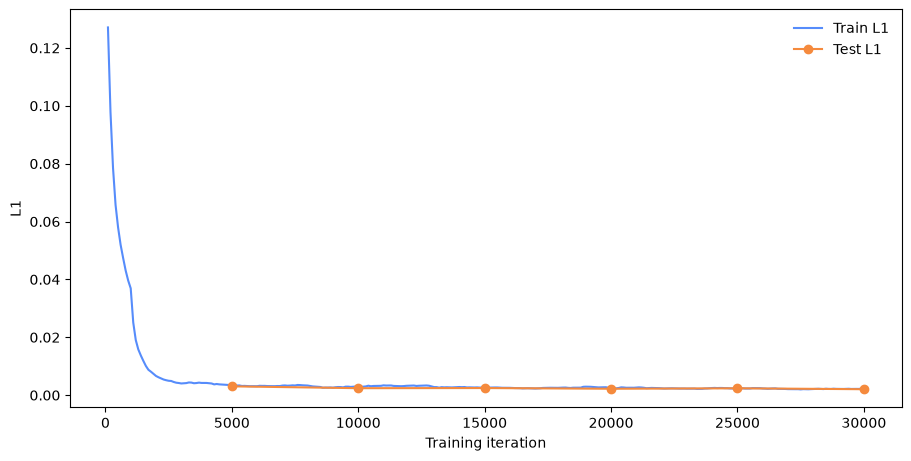

A: lambda_seg=1: segmentation train/test L1 and background in-between loss.


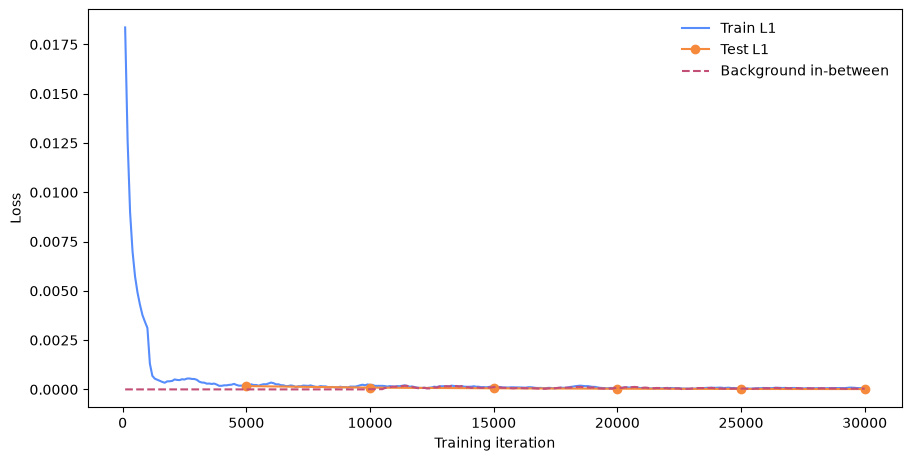

A: lambda_seg=1: reconstruction metrics.


,Split,Slices,L1,PSNR,SSIM,Dice,IoU
0,all,37,0.010350,36.484168,0.995950,0.595288,0.577214
1,observed,13,0.001881,49.209927,0.999929,0.768985,0.768741
2,missing_all,24,0.014937,29.591049,0.993794,0.501202,0.473470
3,tumor_missing,4,0.015760,29.112203,0.992997,0.507214,0.340818
4,empty_missing,20,0.014772,29.686818,0.993953,0.500000,0.500000


A: lambda_seg=1: held-out tumor slices.


,SliceIndex,PSNR,SSIM,Dice,IoU
16,87,28.760405,0.992335,0.464993,0.302926
17,88,28.915918,0.992685,0.547511,0.376947
19,90,29.486467,0.993646,0.550071,0.379377
20,91,29.286020,0.993322,0.466281,0.304020


A: lambda_seg=1: mask extent around the tumor.


,SliceIndex,Observed,TumorGT,GTPixels,PredictedPixels,ScoreMax,ScoreMean,Dice
9,80,True,False,0,0,0,0.000000,1.000000
10,81,False,False,0,3,235,0.004799,0.000000
11,82,False,False,0,17,255,0.021488,0.000000
12,83,True,False,0,21,255,0.028019,0.000000
13,84,False,False,0,44,255,0.055363,0.000000
14,85,False,False,0,98,255,0.118652,0.000000
15,86,True,True,184,184,255,0.179150,1.000000
16,87,False,True,581,176,255,0.185284,0.464993
17,88,False,True,583,301,255,0.321362,0.547511
18,89,True,True,518,518,255,0.504677,1.000000


A: lambda_seg=1: GT and predicted foreground area across CT slices.


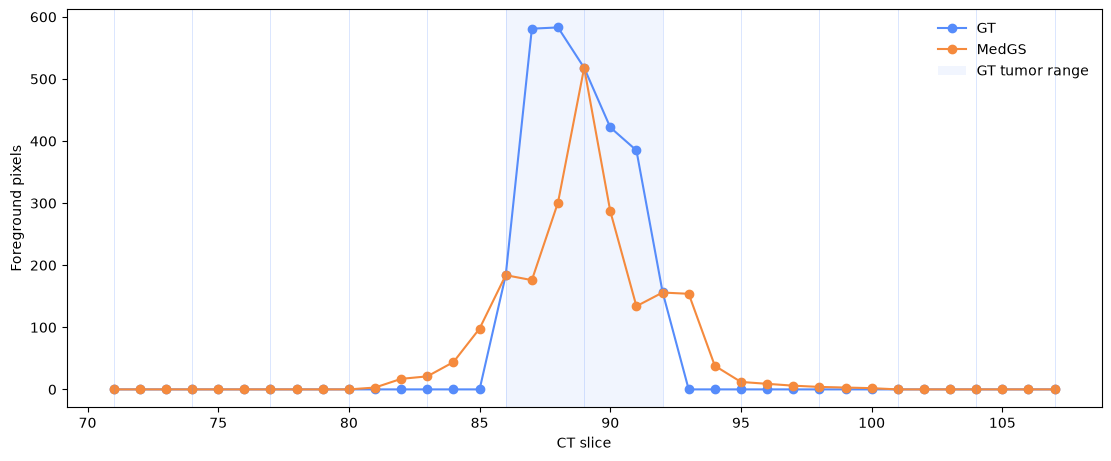

A: lambda_seg=1: threshold sensitivity.


,Threshold,TumorMissingDice,TumorMissingIoU,FalsePositivePixelsOutsideTumor,PositiveSlicesOutsideTumor,PositiveObservedEmptySlices
0,50,0.580225,0.410271,665,13,3
1,75,0.564442,0.394512,568,13,3
2,100,0.546246,0.377424,509,13,3
3,125,0.529698,0.361700,455,13,3
4,150,0.507214,0.340818,411,13,3
5,175,0.485730,0.321530,373,13,3
6,200,0.463460,0.302403,327,13,3
7,225,0.431430,0.275648,298,12,3


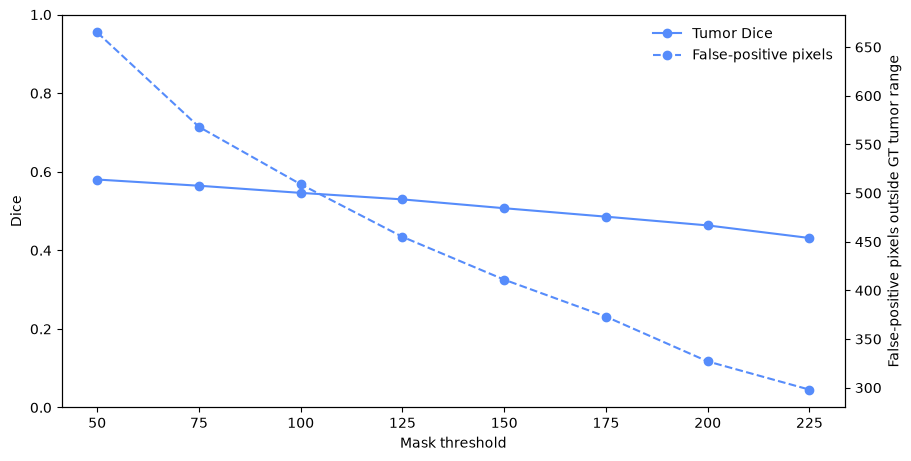

A: lambda_seg=1: mesh reconstruction metrics.


,Value
Metric,
Dice,0.467762
IoU,0.30528
MeanSurfaceDistanceMm,5.15062
HD95Mm,18.629379
CentroidErrorMm,1.785768
VolumeMm3,21596.328647
ReferenceVolumeMm3,8020.063232
VolumeErrorMm3,13576.265415
VolumeErrorPercent,169.278783


A: lambda_seg=1: CT and mask reconstruction for slices 71..107.


A: lambda_seg=1: reference and reconstructed tumor meshes.


In [9]:
result_a = run_experiment(EXPERIMENTS[0])
show_training_history(result_a)
show_segmentation_diagnostics(result_a)
show_reconstruction(result_a)

# 6. Experiment B — $\lambda_{\mathrm{seg}} = 2$

The complete segmentation objective contributes twice as strongly as the image branch. This increases the influence of both observed-mask supervision and the background-aware in-between penalty.

B: lambda_seg=2: training.
torch cuda:  True
Optimizing /home/jovyan/shared/mtm_medgs_stack/results/canonical/patient117_20001024_annotated/phase00_joint_local71_107_stride3_poly7_bginter_v11/B_lambda_seg_2/model
Training with JOINT img+seg loss (no freezing) [02/09 09:22:47]
Output folder: /home/jovyan/shared/mtm_medgs_stack/results/canonical/patient117_20001024_annotated/phase00_joint_local71_107_stride3_poly7_bginter_v11/B_lambda_seg_2/model [02/09 09:22:47]
Tensorboard not available: not logging progress [02/09 09:22:47]
frames(img) 13 [02/09 09:22:47]
frames(seg) 13 [02/09 09:22:47]
Distance: 1.0 [02/09 09:22:47]
Creating Training Transforms [02/09 09:22:47]
Creating Test Transforms [02/09 09:22:47]
AAAAA radius 1.1 [02/09 09:22:47]
AAAAA translate [-0. -0. -0.] center [0. 0. 0.] [02/09 09:22:47]
Generating random point cloud (100000)... [02/09 09:22:47]
Loading Training Cameras [02/09 09:22:48]
Loading Test Cameras [02/09 09:22:48]
Number of points at initialisation :  100000 [02

Training progress: 100%|██████████| 30000/30000 [40:20<00:00, 12.39it/s, Loss=1.0113806, psnr_img=49.88, psnr_seg=59.20, point=202581] 


prev_next_overlap 2 [02/09 09:22:50]

[ITER 5000] (img) Evaluating test: L1 0.0030887457721221908 PSNR 44.80761102529672 [02/09 09:26:49]

[ITER 5000] (seg) Evaluating test: L1 0.00017169550365291587 PSNR inf [02/09 09:26:49]
changed interpolation [02/09 09:31:41]

[ITER 10000] (img) Evaluating test: L1 0.0024153203345262087 PSNR 47.85723378108098 [02/09 09:31:42]

[ITER 10000] (seg) Evaluating test: L1 0.00010368899305793852 PSNR inf [02/09 09:31:42]

[ITER 15000] (img) Evaluating test: L1 0.002490557497367263 PSNR 47.74547899686373 [02/09 09:39:20]

[ITER 15000] (seg) Evaluating test: L1 5.333486550485899e-05 PSNR inf [02/09 09:39:21]

[ITER 20000] (img) Evaluating test: L1 0.002223551291255997 PSNR 48.72932639488807 [02/09 09:47:33]

[ITER 20000] (seg) Evaluating test: L1 3.582953426163071e-05 PSNR inf [02/09 09:47:33]

[ITER 25000] (img) Evaluating test: L1 0.0023305499836659203 PSNR 48.697242736816406 [02/09 09:55:13]

[ITER 25000] (seg) Evaluating test: L1 1.5055232488783497e-05 

/home/jovyan/shared/mtm_medgs_stack/repo/MedGS/render.py:168: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_state, loaded_iter = torch.load(ckpt_path, map_location="cu

Looking for config file in /home/jovyan/shared/mtm_medgs_stack/results/canonical/patient117_20001024_annotated/phase00_joint_local71_107_stride3_poly7_bginter_v11/B_lambda_seg_2/model/cfg_args
Config file found: /home/jovyan/shared/mtm_medgs_stack/results/canonical/patient117_20001024_annotated/phase00_joint_local71_107_stride3_poly7_bginter_v11/B_lambda_seg_2/model/cfg_args
Rendering /home/jovyan/shared/mtm_medgs_stack/results/canonical/patient117_20001024_annotated/phase00_joint_local71_107_stride3_poly7_bginter_v11/B_lambda_seg_2/model
Distance: 1.0 [02/09 10:03:14]
Loading trained model at iteration 30000 [02/09 10:03:14]
Creating Training Transforms [02/09 10:03:14]
Creating Test Transforms [02/09 10:03:14]
AAAAA radius 1.1 [02/09 10:03:15]
AAAAA translate [-0. -0. -0.] center [0. 0. 0.] [02/09 10:03:15]
Generating random point cloud (100000)... [02/09 10:03:15]
Loading Training Cameras [02/09 10:03:15]
Loading Test Cameras [02/09 10:03:15]
Loading checkpoint: /home/jovyan/shared/

...

[render] chunk 3/4: views 8..11 [02/09 10:03:17]


Rendering progress:   0%|          | 0/1 [00:00<?, ?it/s]

[render] chunk 4/4: views 12..12 [02/09 10:03:18]


Rendering progress: 100%|██████████| 1/1 [00:00<00:00, 35.54it/s]


B: lambda_seg=2: building tumor mesh.
caseing PLY: [=======================================>] 97%
Volume shape (slices, height, width): (37, 512, 512)
Saved mesh to /home/jovyan/shared/mtm_medgs_stack/results/canonical/patient117_20001024_annotated/phase00_joint_local71_107_stride3_poly7_bginter_v11/B_lambda_seg_2/mesh/case.ply
Writing PLY: [========================================] 100%
B: lambda_seg=2: image train/test L1.


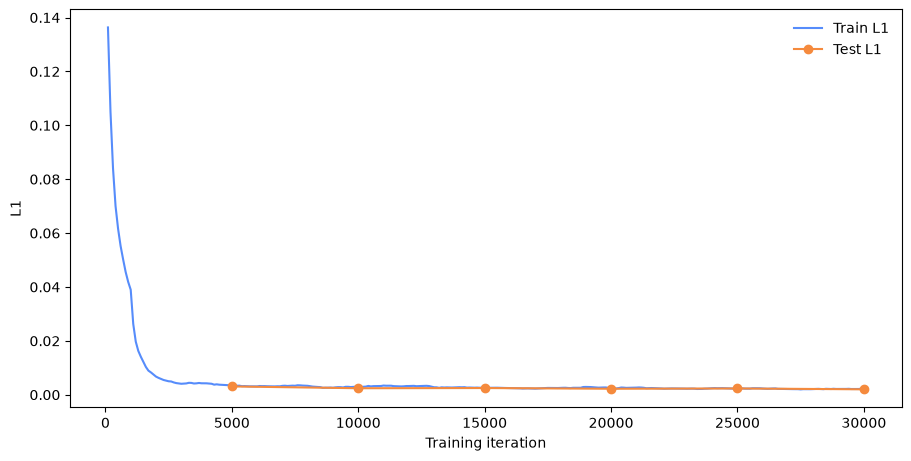

B: lambda_seg=2: segmentation train/test L1 and background in-between loss.


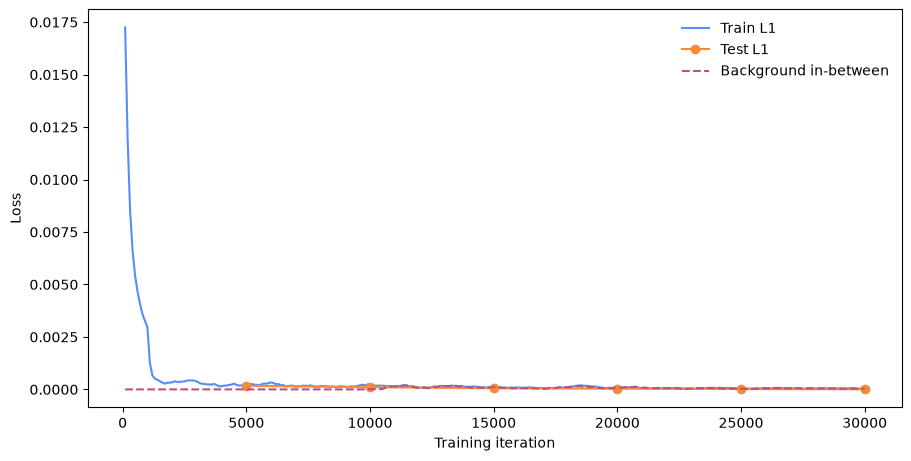

B: lambda_seg=2: reconstruction metrics.


,Split,Slices,L1,PSNR,SSIM,Dice,IoU
0,all,37,0.010345,36.531666,0.995952,0.743269,0.726437
1,observed,13,0.001841,49.343915,0.999931,0.923077,0.923077
2,missing_all,24,0.014951,29.591698,0.993796,0.645874,0.619923
3,tumor_missing,4,0.015697,29.136407,0.993040,0.625241,0.469539
4,empty_missing,20,0.014802,29.682756,0.993947,0.650000,0.650000


B: lambda_seg=2: held-out tumor slices.


,SliceIndex,PSNR,SSIM,Dice,IoU
16,87,28.808655,0.992423,0.476440,0.312715
17,88,28.977983,0.992789,0.784913,0.645973
19,90,29.483849,0.993643,0.737767,0.584493
20,91,29.275141,0.993305,0.501845,0.334975


B: lambda_seg=2: mask extent around the tumor.


,SliceIndex,Observed,TumorGT,GTPixels,PredictedPixels,ScoreMax,ScoreMean,Dice
9,80,True,False,0,0,0,0.000000,1.000000
10,81,False,False,0,3,193,0.004551,0.000000
11,82,False,False,0,25,255,0.025383,0.000000
12,83,True,False,0,19,255,0.020603,0.000000
13,84,False,False,0,36,255,0.038807,0.000000
14,85,False,False,0,71,255,0.083344,0.000000
15,86,True,True,184,184,255,0.179138,1.000000
16,87,False,True,581,183,255,0.193817,0.476440
17,88,False,True,583,398,255,0.408161,0.784913
18,89,True,True,518,518,255,0.504177,1.000000


B: lambda_seg=2: GT and predicted foreground area across CT slices.


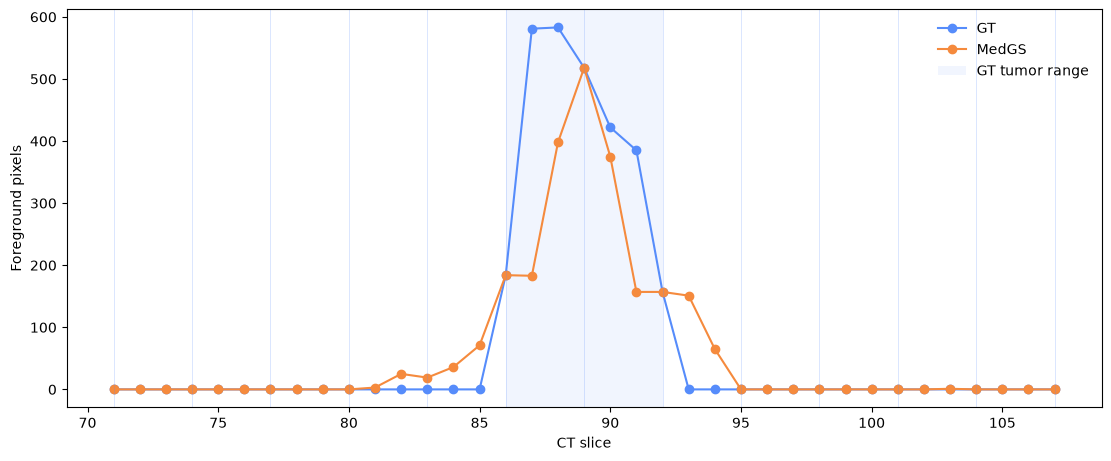

B: lambda_seg=2: threshold sensitivity.


,Threshold,TumorMissingDice,TumorMissingIoU,FalsePositivePixelsOutsideTumor,PositiveSlicesOutsideTumor,PositiveObservedEmptySlices
0,50,0.698545,0.559058,532,11,2
1,75,0.684787,0.542606,473,9,2
2,100,0.670751,0.526691,432,9,2
3,125,0.647273,0.496596,402,8,1
4,150,0.625241,0.469539,371,8,1
5,175,0.599450,0.440895,336,8,1
6,200,0.561184,0.397272,304,6,1
7,225,0.515931,0.351350,275,6,1


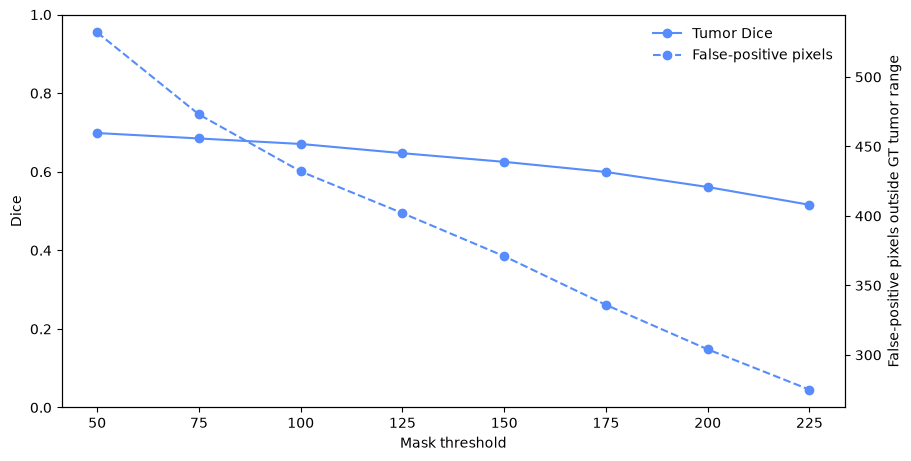

B: lambda_seg=2: mesh reconstruction metrics.


,Value
Metric,
Dice,0.451657
IoU,0.291704
MeanSurfaceDistanceMm,5.476014
HD95Mm,18.755978
CentroidErrorMm,1.030185
VolumeMm3,25269.557318
ReferenceVolumeMm3,8020.063232
VolumeErrorMm3,17249.494086
VolumeErrorPercent,215.079278


B: lambda_seg=2: CT and mask reconstruction for slices 71..107.


B: lambda_seg=2: reference and reconstructed tumor meshes.


In [10]:
result_b = run_experiment(EXPERIMENTS[1])
show_training_history(result_b)
show_segmentation_diagnostics(result_b)
show_reconstruction(result_b)

In [15]:
train_history = pd.read_csv(
    result_b["model_dir"] / "history" / "train_l1.csv"
)

bg = train_history.loc[
    train_history["iteration"] >= 10_000,
    "seg_bg_inter",
]

print("Background in-between loss after 10k:")
print("min :", bg.min())
print("mean:", bg.mean())
print("max :", bg.max())
print("non-zero:", (bg > 0).sum(), "/", len(bg))

Background in-between loss after 10k:
min : 0.0
mean: 7.277952569721944e-05
max : 0.0005301280762068
non-zero: 136 / 201


# 7. Experiment C — $\lambda_{\mathrm{seg}} = 3$

The segmentation branch receives the strongest weight. This tests whether stronger supervision further restricts false-positive extent while preserving the tumor on held-out slices.

C: lambda_seg=3: training.
torch cuda:  True
Optimizing /home/jovyan/shared/mtm_medgs_stack/results/canonical/patient117_20001024_annotated/phase00_joint_local71_107_stride3_poly7_bginter_v11/C_lambda_seg_3/model
Training with JOINT img+seg loss (no freezing) [02/09 10:03:43]
Output folder: /home/jovyan/shared/mtm_medgs_stack/results/canonical/patient117_20001024_annotated/phase00_joint_local71_107_stride3_poly7_bginter_v11/C_lambda_seg_3/model [02/09 10:03:43]
Tensorboard not available: not logging progress [02/09 10:03:43]
frames(img) 13 [02/09 10:03:43]
frames(seg) 13 [02/09 10:03:43]
Distance: 1.0 [02/09 10:03:43]
Creating Training Transforms [02/09 10:03:43]
Creating Test Transforms [02/09 10:03:43]
AAAAA radius 1.1 [02/09 10:03:43]
AAAAA translate [-0. -0. -0.] center [0. 0. 0.] [02/09 10:03:43]
Generating random point cloud (100000)... [02/09 10:03:43]
Loading Training Cameras [02/09 10:03:43]
Loading Test Cameras [02/09 10:03:44]
Number of points at initialisation :  100000 [02

Training progress: 100%|██████████| 30000/30000 [39:20<00:00, 12.71it/s, Loss=1.5025774, psnr_img=49.95, psnr_seg=44.25, point=213525] 


prev_next_overlap 2 [02/09 10:03:45]

[ITER 5000] (img) Evaluating test: L1 0.0030528705280560716 PSNR 45.22843933105469 [02/09 10:07:48]

[ITER 5000] (seg) Evaluating test: L1 0.00015245379752461583 PSNR inf [02/09 10:07:48]
changed interpolation [02/09 10:12:37]

[ITER 10000] (img) Evaluating test: L1 0.002417737922559564 PSNR 47.855098724365234 [02/09 10:12:37]

[ITER 10000] (seg) Evaluating test: L1 9.635438258094919e-05 PSNR inf [02/09 10:12:37]

[ITER 15000] (img) Evaluating test: L1 0.002450882958678099 PSNR 47.82858892587515 [02/09 10:20:09]

[ITER 15000] (seg) Evaluating test: L1 6.995491954652467e-05 PSNR inf [02/09 10:20:10]

[ITER 20000] (img) Evaluating test: L1 0.00219836500652421 PSNR 48.919092618502106 [02/09 10:28:09]

[ITER 20000] (seg) Evaluating test: L1 4.815283240042425e-05 PSNR inf [02/09 10:28:09]

[ITER 25000] (img) Evaluating test: L1 0.002458715739731605 PSNR 48.21437718318059 [02/09 10:35:37]

[ITER 25000] (seg) Evaluating test: L1 2.004730292635661e-05 PSNR

/home/jovyan/shared/mtm_medgs_stack/repo/MedGS/render.py:168: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_state, loaded_iter = torch.load(ckpt_path, map_location="cu

Looking for config file in /home/jovyan/shared/mtm_medgs_stack/results/canonical/patient117_20001024_annotated/phase00_joint_local71_107_stride3_poly7_bginter_v11/C_lambda_seg_3/model/cfg_args
Config file found: /home/jovyan/shared/mtm_medgs_stack/results/canonical/patient117_20001024_annotated/phase00_joint_local71_107_stride3_poly7_bginter_v11/C_lambda_seg_3/model/cfg_args
Rendering /home/jovyan/shared/mtm_medgs_stack/results/canonical/patient117_20001024_annotated/phase00_joint_local71_107_stride3_poly7_bginter_v11/C_lambda_seg_3/model
Distance: 1.0 [02/09 10:43:10]
Loading trained model at iteration 30000 [02/09 10:43:10]
Creating Training Transforms [02/09 10:43:10]
Creating Test Transforms [02/09 10:43:10]
AAAAA radius 1.1 [02/09 10:43:11]
AAAAA translate [-0. -0. -0.] center [0. 0. 0.] [02/09 10:43:11]
Generating random point cloud (100000)... [02/09 10:43:11]
Loading Training Cameras [02/09 10:43:11]
Loading Test Cameras [02/09 10:43:11]
Loading checkpoint: /home/jovyan/shared/

...

[render] chunk 3/4: views 8..11 [02/09 10:43:14]


Rendering progress: 100%|██████████| 4/4 [00:00<00:00, 26.48it/s]


[render] chunk 4/4: views 12..12 [02/09 10:43:14]


Rendering progress: 100%|██████████| 1/1 [00:00<00:00, 34.74it/s]


C: lambda_seg=3: building tumor mesh.
caseing PLY: [=======================================>] 97%
Volume shape (slices, height, width): (37, 512, 512)
Saved mesh to /home/jovyan/shared/mtm_medgs_stack/results/canonical/patient117_20001024_annotated/phase00_joint_local71_107_stride3_poly7_bginter_v11/C_lambda_seg_3/mesh/case.ply
Writing PLY: [========================================] 100%
C: lambda_seg=3: image train/test L1.


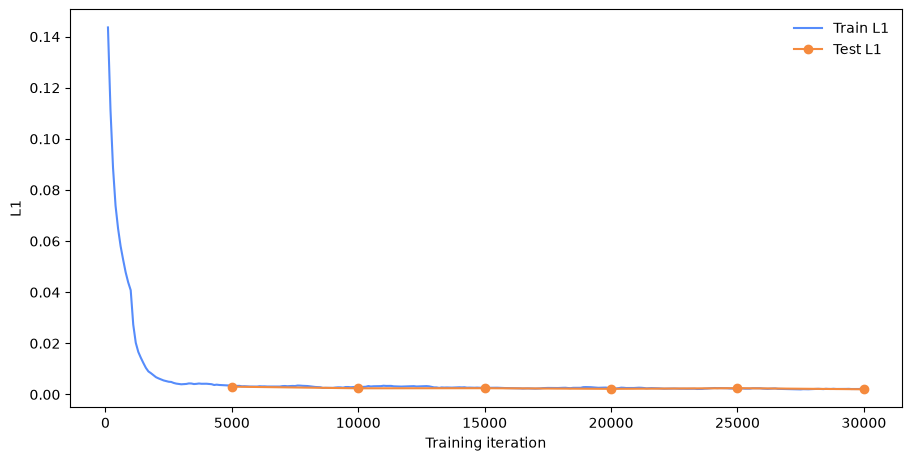

C: lambda_seg=3: segmentation train/test L1 and background in-between loss.


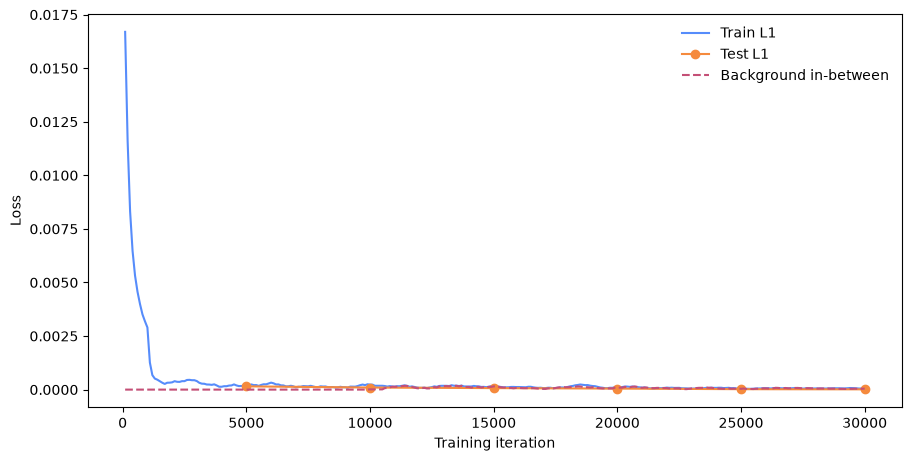

C: lambda_seg=3: reconstruction metrics.


,Split,Slices,L1,PSNR,SSIM,Dice,IoU
0,all,37,0.010325,36.562375,0.995996,0.570175,0.552054
1,observed,13,0.001857,49.348359,0.999931,0.692308,0.692308
2,missing_all,24,0.014911,29.636633,0.993864,0.504020,0.476083
3,tumor_missing,4,0.015717,29.165495,0.993088,0.524117,0.356500
4,empty_missing,20,0.014750,29.730861,0.994019,0.500000,0.500000


C: lambda_seg=3: held-out tumor slices.


,SliceIndex,PSNR,SSIM,Dice,IoU
16,87,28.889824,0.992558,0.479058,0.314974
17,88,29.009018,0.992840,0.587852,0.416283
19,90,29.475754,0.993631,0.550279,0.379576
20,91,29.287386,0.993324,0.479279,0.315166


C: lambda_seg=3: mask extent around the tumor.


,SliceIndex,Observed,TumorGT,GTPixels,PredictedPixels,ScoreMax,ScoreMean,Dice
9,80,True,False,0,0,0,0.000000,1.000000
10,81,False,False,0,6,237,0.008221,0.000000
11,82,False,False,0,19,255,0.020996,0.000000
12,83,True,False,0,15,255,0.017567,0.000000
13,84,False,False,0,43,255,0.049828,0.000000
14,85,False,False,0,101,255,0.123371,0.000000
15,86,True,True,184,184,255,0.179127,1.000000
16,87,False,True,581,183,255,0.202366,0.479058
17,88,False,True,583,339,255,0.369541,0.587852
18,89,True,True,518,518,255,0.504108,1.000000


C: lambda_seg=3: GT and predicted foreground area across CT slices.


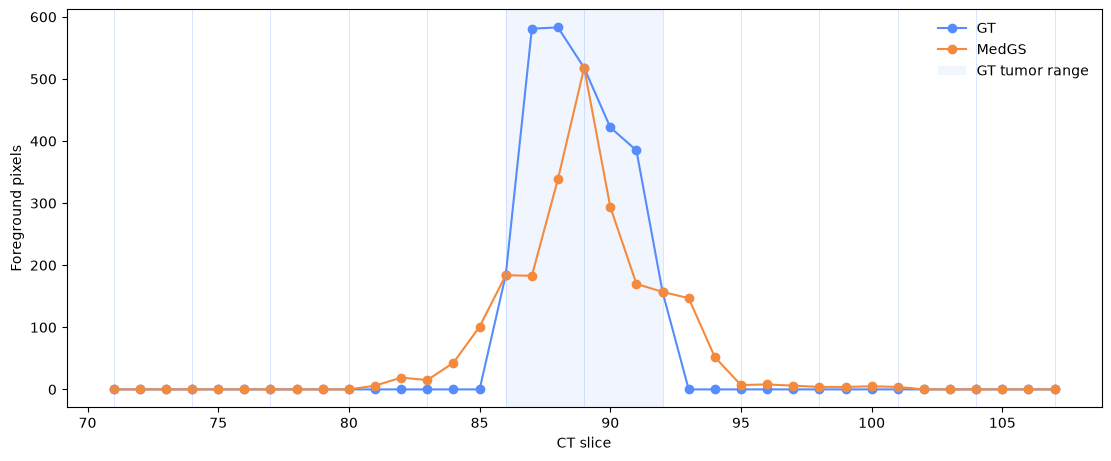

C: lambda_seg=3: threshold sensitivity.


,Threshold,TumorMissingDice,TumorMissingIoU,FalsePositivePixelsOutsideTumor,PositiveSlicesOutsideTumor,PositiveObservedEmptySlices
0,50,0.602789,0.435130,677,14,4
1,75,0.582865,0.414217,594,14,4
2,100,0.565368,0.396701,517,14,4
3,125,0.542261,0.373948,473,14,4
4,150,0.524117,0.356500,421,14,4
5,175,0.504904,0.338828,384,14,4
6,200,0.478903,0.315581,361,14,4
7,225,0.450393,0.291129,323,14,4


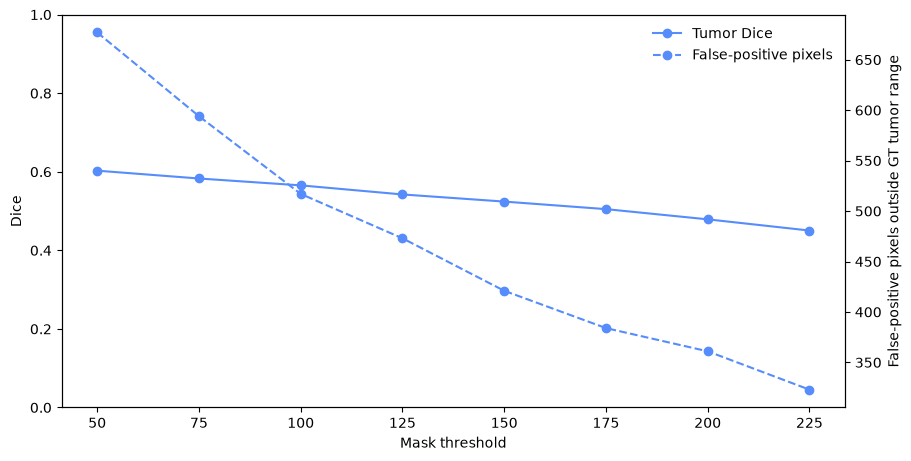

C: lambda_seg=3: mesh reconstruction metrics.


,Value
Metric,
Dice,0.471981
IoU,0.308884
MeanSurfaceDistanceMm,5.189965
HD95Mm,18.804413
CentroidErrorMm,1.490891
VolumeMm3,22822.801066
ReferenceVolumeMm3,8020.063232
VolumeErrorMm3,14802.737834
VolumeErrorPercent,184.571336


C: lambda_seg=3: CT and mask reconstruction for slices 71..107.


C: lambda_seg=3: reference and reconstructed tumor meshes.


In [11]:
result_c = run_experiment(EXPERIMENTS[2])
show_training_history(result_c)
show_segmentation_diagnostics(result_c)
show_reconstruction(result_c)

# 8. Comparison

In [12]:
comparison_rows = []

for result in [result_a, result_b, result_c]:
    experiment = result["experiment"]
    summary = result["summary"]
    threshold_results = result["threshold_results"]
    mesh_metrics = result["mesh_metrics"]

    tumor_row = summary.loc[
        summary["Split"] == "tumor_missing"
        ].iloc[0]

    threshold_row = threshold_results.loc[
        threshold_results["Threshold"] == MASK_THRESHOLD
        ].iloc[0]

    comparison_rows.append(
        {
            "Experiment": experiment["key"],
            "LambdaSeg": float(experiment["lambda_seg"]),
            "TumorMissingPSNR": float(tumor_row["PSNR"]),
            "TumorMissingDice": float(tumor_row["Dice"]),
            "TumorMissingIoU": float(tumor_row["IoU"]),
            "FalsePositivePixelsOutsideTumor": int(
                threshold_row["FalsePositivePixelsOutsideTumor"]
            ),
            "PositiveSlicesOutsideTumor": int(
                threshold_row["PositiveSlicesOutsideTumor"]
            ),
            "PositiveObservedEmptySlices": int(
                threshold_row["PositiveObservedEmptySlices"]
            ),
            "MeshDice": (
                float(mesh_metrics["Dice"])
                if mesh_metrics is not None
                else np.nan
            ),
            "HD95Mm": (
                float(mesh_metrics["HD95Mm"])
                if mesh_metrics is not None
                else np.nan
            ),
            "VolumeErrorPercent": (
                float(mesh_metrics["VolumeErrorPercent"])
                if mesh_metrics is not None
                else np.nan
            ),
        }
    )

comparison = pd.DataFrame(comparison_rows)
comparison.to_csv(
    V11_ROOT / "v11_abc_comparison.csv",
    index=False,
)

print("A/B/C comparison:")
display(comparison)

print(
    "Highest tumor-missing Dice:",
    comparison.loc[
        comparison["TumorMissingDice"].idxmax(),
        "Experiment",
    ],
)
print(
    "Fewest positive slices outside tumor:",
    comparison.loc[
        comparison["PositiveSlicesOutsideTumor"].idxmin(),
        "Experiment",
    ],
)
print(
    "Highest mesh Dice:",
    comparison.loc[
        comparison["MeshDice"].idxmax(),
        "Experiment",
    ],
)
print(
    "Lowest HD95:",
    comparison.loc[
        comparison["HD95Mm"].idxmin(),
        "Experiment",
    ],
)

A/B/C comparison:


,Experiment,LambdaSeg,TumorMissingPSNR,TumorMissingDice,TumorMissingIoU,FalsePositivePixelsOutsideTumor,PositiveSlicesOutsideTumor,PositiveObservedEmptySlices,MeshDice,HD95Mm,VolumeErrorPercent
0,A,1.0,29.112203,0.507214,0.340818,411,13,3,0.467762,18.629379,169.278783
1,B,2.0,29.136407,0.625241,0.469539,371,8,1,0.451657,18.755978,215.079278
2,C,3.0,29.165495,0.524117,0.356500,421,14,4,0.471981,18.804413,184.571336


Highest tumor-missing Dice: B
Fewest positive slices outside tumor: B
Highest mesh Dice: C
Lowest HD95: A


GT and reconstructed foreground area for all experiments:


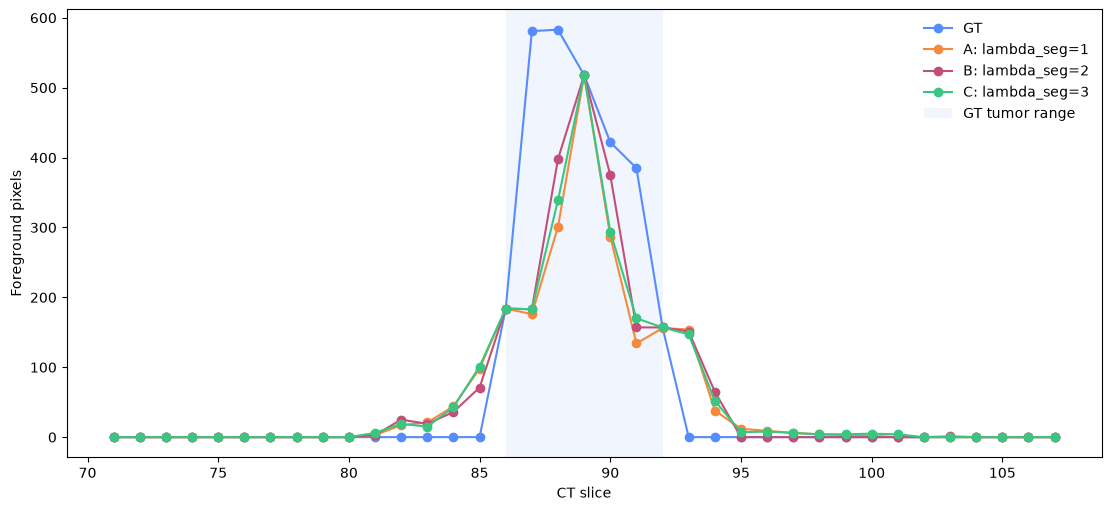

In [13]:
import matplotlib.pyplot as plt

print("GT and reconstructed foreground area for all experiments:")

figure, axis = plt.subplots(
    figsize=(11, 5),
    constrained_layout=True,
)

axis.plot(
    result_a["mask_diagnostics"]["SliceIndex"],
    result_a["mask_diagnostics"]["GTPixels"],
    marker="o",
    label="GT",
)

for result in [result_a, result_b, result_c]:
    diagnostics = result["mask_diagnostics"]
    axis.plot(
        diagnostics["SliceIndex"],
        diagnostics["PredictedPixels"],
        marker="o",
        label=result["experiment"]["label"],
    )

axis.axvspan(
    TUMOR_START,
    TUMOR_END,
    alpha=0.08,
    label="GT tumor range",
)

axis.set_xlabel("CT slice")
axis.set_ylabel("Foreground pixels")
axis.legend(frameon=False)

figure.savefig(
    V11_ROOT / "v11_abc_foreground_by_slice.png",
    dpi=250,
    bbox_inches="tight",
)

plt.show()

# 9. Saved outputs

Each experiment saves `experiment_config.json`, per-slice metrics, summary metrics, segmentation diagnostics, threshold sweep, mesh metrics, train/test history and figures in its own run directory.

The root directory also contains the A/B/C comparison table and the combined foreground-by-slice figure. These files can later be loaded directly by a separate cross-experiment results notebook without retraining.